In [ ]:
from datasets import load_dataset
ds = load_dataset("wikiann", "hi")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

hi/validation-00000-of-00001.parquet:   0%|          | 0.00/64.7k [00:00<?, ?B/s]

hi/test-00000-of-00001.parquet:   0%|          | 0.00/65.0k [00:00<?, ?B/s]

hi/train-00000-of-00001.parquet:   0%|          | 0.00/312k [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/5000 [00:00<?, ? examples/s]

In [ ]:
!pip install transformers datasets torch evaluate seqeval matplotlib -q
!pip install evaluate -q
!pip install seqeval -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.3 MB/s eta 0:00:00


In [ ]:
!pip install evaluate seqeval -q

In [ ]:
ds

DatasetDict({
    validation: Dataset({
        features: ['tokens', 'ner_tags', 'langs', 'spans'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['tokens', 'ner_tags', 'langs', 'spans'],
        num_rows: 1000
    })
    train: Dataset({
        features: ['tokens', 'ner_tags', 'langs', 'spans'],
        num_rows: 5000
    })
})

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from datasets import load_dataset, concatenate_datasets, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification
)
import evaluate

print(f'GPU available: {torch.cuda.is_available()}')

GPU available: True


In [ ]:
!nvidia-smi

Fri Apr 10 05:13:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
LABEL_LIST = [
    'O',
    'B-PER',
    'I-PER',
    'B-ORG',
    'I-ORG',
    'B-LOC',
    'I-LOC',
]

LABEL2ID = {label: i for i, label in enumerate(LABEL_LIST)}
ID2LABEL = {i: label for i, label in enumerate(LABEL_LIST)}

print('Labels:')
for i, label in ID2LABEL.items():
    print(f'  {i} → {label}')

Labels:
  0 → O
  1 → B-PER
  2 → I-PER
  3 → B-ORG
  4 → I-ORG
  5 → B-LOC
  6 → I-LOC


In [ ]:


from datasets import load_dataset

# Existing datasets
en_data = load_dataset('wikiann', 'en')
print('English')

hi_data = load_dataset('wikiann', 'hi')
print('Hindi')

ta_data = load_dataset('wikiann', 'ta')
print('Tamil')

bn_data = load_dataset('wikiann', 'bn')
print('Bengali')


pa_data = load_dataset('wikiann', 'pa')
print('Punjabi')

print()
print('Dataset sizes:')
print(f'  English : Train={len(en_data["train"]):,} | Test={len(en_data["test"]):,}')
print(f'  Hindi   : Train={len(hi_data["train"]):,} | Test={len(hi_data["test"]):,}')
print(f'  Tamil   : Train={len(ta_data["train"]):,} | Test={len(ta_data["test"]):,}')
print(f'  Bengali : Train={len(bn_data["train"]):,} | Test={len(bn_data["test"]):,}')
print(f'  Punjabi : Train={len(pa_data["train"]):,} | Test={len(pa_data["test"]):,}')

en/validation-00000-of-00001.parquet:   0%|          | 0.00/748k [00:00<?, ?B/s]

en/test-00000-of-00001.parquet:   0%|          | 0.00/748k [00:00<?, ?B/s]

en/train-00000-of-00001.parquet:   0%|          | 0.00/1.50M [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

...

pa/train-00000-of-00001.parquet:   0%|          | 0.00/10.4k [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/100 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/100 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/100 [00:00<?, ? examples/s]

Punjabi

Dataset sizes:
  English : Train=20,000 | Test=10,000
  Hindi   : Train=5,000 | Test=1,000
  Tamil   : Train=15,000 | Test=1,000
  Bengali : Train=10,000 | Test=1,000
  Punjabi : Train=100 | Test=100


In [ ]:
ID2LABEL = en_data["train"].features["ner_tags"].feature.names

print('English Sample')
sample = en_data['train'][0]
print(f'Tokens : {sample["tokens"]}')
print(f'Tags   : {sample["ner_tags"]}')
print(f'Labels : {[ID2LABEL[t] for t in sample["ner_tags"]]}')

print()
print('Hindi Sample')
sample = hi_data['train'][0]
print(f'Tokens : {sample["tokens"]}')
print(f'Labels : {[ID2LABEL[t] for t in sample["ner_tags"]]}')

print()
print('Bengali Sample')
sample = bn_data['train'][0]
print(f'Tokens : {sample["tokens"]}')
print(f'Labels : {[ID2LABEL[t] for t in sample["ner_tags"]]}')

print()
print('Tamil Sample')
sample = ta_data['train'][0]
print(f'Tokens : {sample["tokens"]}')
print(f'Labels : {[ID2LABEL[t] for t in sample["ner_tags"]]}')

print()
print('Punjabi Sample')
sample = pa_data['train'][0]
print(f'Tokens : {sample["tokens"]}')
print(f'Labels : {[ID2LABEL[t] for t in sample["ner_tags"]]}')

English Sample
Tokens : ['R.H.', 'Saunders', '(', 'St.', 'Lawrence', 'River', ')', '(', '968', 'MW', ')']
Tags   : [3, 4, 0, 3, 4, 4, 0, 0, 0, 0, 0]
Labels : ['B-ORG', 'I-ORG', 'O', 'B-ORG', 'I-ORG', 'I-ORG', 'O', 'O', 'O', 'O', 'O']

Hindi Sample
Tokens : ['टैपी', 'ने', 'अपने', 'उत्पादों', 'को', 'एशिया', 'के', 'अपतटीय', 'भागों', 'में', 'भेजने', 'का', 'फैसला', 'लिया।', 'उन्होंने', 'प्रोमोशन', 'के', 'लिए', 'मैडोना', 'को', 'अपने', 'साथ', 'मिलाया।']
Labels : ['O', 'O', 'O', 'O', 'O', 'B-LOC', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-PER', 'O', 'O', 'O', 'O']

Bengali Sample
Tokens : ['ড্যানভিল', ',', 'ইলিনয়']
Labels : ['B-LOC', 'I-LOC', 'I-LOC']

Tamil Sample
Tokens : ['இங்கிருக்கும்', 'அரச', 'மரம்', 'தேவனம்பியதீச', 'மன்னன்', 'காலத்திலேயே', 'அனுராதபுரத்திலிருக்கும்', 'சிறீ', 'மகாபோதியிலிருந்து', 'முதலாவதாகப்', 'பிரித்தெடுத்து', 'நடப்பட்டதாகும்', '.']
Labels : ['O', 'B-LOC', 'I-LOC', 'B-PER', 'O', 'O', 'O', 'B-ORG', 'I-ORG', 'O', 'O', 'O', 'O']

Punjabi Sample
Tokens

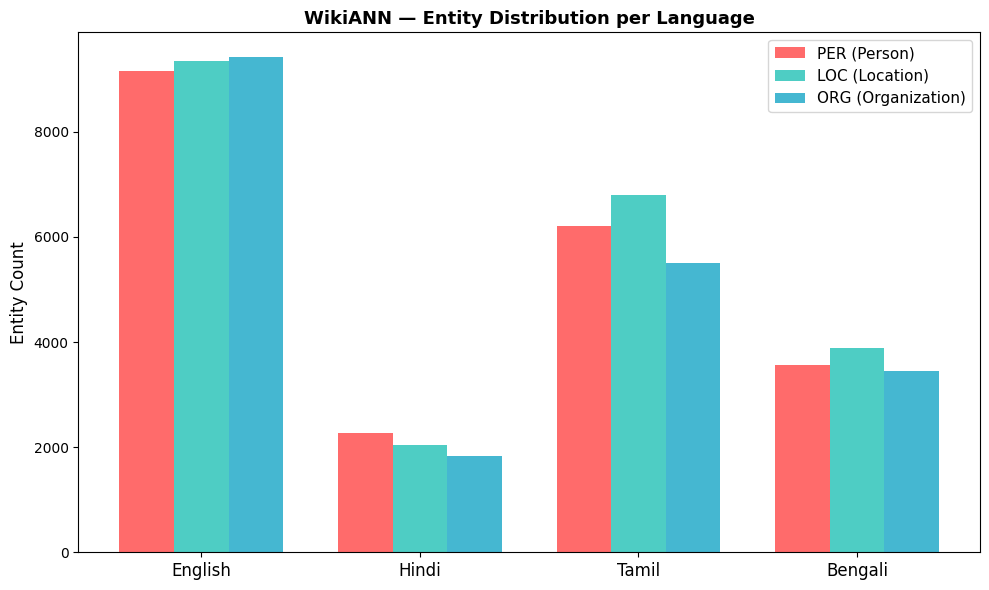


Counts:
  English    → PER: 9164 | LOC: 9345 | ORG: 9422
  Hindi      → PER: 2261 | LOC: 2040 | ORG: 1823
  Tamil      → PER: 6206 | LOC: 6791 | ORG: 5497
  Bengali    → PER: 3568 | LOC: 3885 | ORG: 3444


In [ ]:
def count_labels(dataset):
    all_labels = []
    for sample in dataset['train']:
        all_labels.extend([ID2LABEL[t] for t in sample['ner_tags']])
    counts = Counter(all_labels)
    return {
        'PER': counts.get('B-PER', 0),
        'LOC': counts.get('B-LOC', 0),
        'ORG': counts.get('B-ORG', 0),
    }

en_counts = count_labels(en_data)
hi_counts = count_labels(hi_data)
ta_counts = count_labels(ta_data)
bn_counts = count_labels(bn_data)

languages = ['English', 'Hindi', 'Tamil', 'Bengali']
per_vals  = [en_counts['PER'], hi_counts['PER'], ta_counts['PER'], bn_counts['PER']]
loc_vals  = [en_counts['LOC'], hi_counts['LOC'], ta_counts['LOC'], bn_counts['LOC']]
org_vals  = [en_counts['ORG'], hi_counts['ORG'], ta_counts['ORG'], bn_counts['ORG']]

x = np.arange(len(languages))
w = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - w, per_vals, w, label='PER (Person)',       color='#FF6B6B')
ax.bar(x,     loc_vals, w, label='LOC (Location)',     color='#4ECDC4')
ax.bar(x + w, org_vals, w, label='ORG (Organization)', color='#45B7D1')

ax.set_xticks(x)
ax.set_xticklabels(languages, fontsize=12)
ax.set_ylabel('Entity Count', fontsize=12)
ax.set_title('WikiANN — Entity Distribution per Language', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print('\nCounts:')
for lang, ec, lc, oc in zip(languages, per_vals, loc_vals, org_vals):
    print(f'  {lang:10s} → PER:{ec:5d} | LOC:{lc:5d} | ORG:{oc:5d}')

pa_counts = count_labels(pa_data)



In [ ]:
from datasets import DatasetDict, concatenate_datasets

combined_dataset = DatasetDict({
    'train': concatenate_datasets([
        en_data['train'],
        hi_data['train'],
        ta_data['train'],
        bn_data['train'],
        pa_data['train'],
    ]).shuffle(seed=42),

    'validation': concatenate_datasets([
        en_data['validation'],
        hi_data['validation'],
        ta_data['validation'],
        bn_data['validation'],
        pa_data['validation'],
    ]),

    'test': concatenate_datasets([
        en_data['test'],
        hi_data['test'],
        ta_data['test'],
        bn_data['test'],
        pa_data['test'],
    ]),
})

print('Combined Dataset:')
print(f'  Train      : {len(combined_dataset["train"]):,} samples')
print(f'  Validation : {len(combined_dataset["validation"]):,} samples')
print(f'  Test       : {len(combined_dataset["test"]):,} samples')
print(f'  Total      : {len(combined_dataset["train"]) + len(combined_dataset["validation"]) + len(combined_dataset["test"]):,} samples')

Combined Dataset:
  Train      : 50,100 samples
  Validation : 13,100 samples
  Test       : 13,100 samples
  Total      : 76,300 samples


In [ ]:
MODEL_NAME = 'xlm-roberta-base'

print(f'Tokenizer load : {MODEL_NAME}')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print('Tokenizer ready!')


test_text = 'Narendra Modi visited Delhi'
tokens    = tokenizer.tokenize(test_text)
print(f'\nTest: "{test_text}"')
print(f'Tokens: {tokens}')

Tokenizer load : xlm-roberta-base


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer ready!

Test: "Narendra Modi visited Delhi"
Tokens: ['▁Narendra', '▁Modi', '▁visite', 'd', '▁Delhi']


In [ ]:
def tokenize_and_align(examples):
    tokenized = tokenizer(
        examples['tokens'],
        truncation=True,
        is_split_into_words=True,
        max_length=256,
        padding='max_length',
    )

    all_labels = []
    for i, labels in enumerate(examples['ner_tags']):
        word_ids  = tokenized.word_ids(batch_index=i)
        prev_word = None
        label_ids = []

        for word_id in word_ids:
            if word_id is None:
                label_ids.append(-100)
            elif word_id != prev_word:
                label_ids.append(labels[word_id])
            else:
                label_ids.append(-100)
            prev_word = word_id

        all_labels.append(label_ids)

    tokenized['labels'] = all_labels
    return tokenized


tokenized_dataset = combined_dataset.map(
    tokenize_and_align,
    batched=True,
    remove_columns=combined_dataset['train'].column_names,
)
print('Tokenization complete!')
print(tokenized_dataset)

Map:   0%|          | 0/50100 [00:00<?, ? examples/s]

Map:   0%|          | 0/13100 [00:00<?, ? examples/s]

Map:   0%|          | 0/13100 [00:00<?, ? examples/s]

Tokenization complete!
DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 50100
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 13100
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 13100
    })
})


In [ ]:
def tokenize_and_align(examples):
    tokenized = tokenizer(
        examples['tokens'],
        truncation=True,
        is_split_into_words=True,
        max_length=256,
        padding='max_length',
    )

    all_labels = []
    for i, labels in enumerate(examples['ner_tags']):
        word_ids  = tokenized.word_ids(batch_index=i)
        prev_word = None
        label_ids = []

        for word_id in word_ids:
            if word_id is None:
                label_ids.append(-100)
            elif word_id != prev_word:
                label_ids.append(labels[word_id])
            else:
                label_ids.append(-100)
            prev_word = word_id

        all_labels.append(label_ids)

    tokenized['labels'] = all_labels
    return tokenized

print('Dataset tokenize ho raha hai...')
tokenized_dataset = combined_dataset.map(
    tokenize_and_align,
    batched=True,
    remove_columns=combined_dataset['train'].column_names,
)
print('Tokenization complete!')
print(tokenized_dataset)

Dataset tokenize ho raha hai...


Map:   0%|          | 0/50100 [00:00<?, ? examples/s]

Tokenization complete!
DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 50100
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 13100
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 13100
    })
})


In [ ]:
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels = len(LABEL_LIST),
    id2label   = ID2LABEL,
    label2id   = LABEL2ID,
)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print('Model ready!')
print(f'  Model name          : {MODEL_NAME}')
print(f'  Total parameters    : {total:,}')
print(f'  Trainable parameters: {trainable:,}')
print(f'  Number of labels    : {len(LABEL_LIST)}')
print(f'  Labels              : {LABEL_LIST}')

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForTokenClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.bias             | MISSING    | 
classifier.weight           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model ready!
  Model name          : xlm-roberta-base
  Total parameters    : 277,458,439
  Trainable parameters: 277,458,439
  Number of labels    : 7
  Labels              : ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC']


In [ ]:
LABEL_LIST = en_data["train"].features["ner_tags"].feature.names

ID2LABEL = {i: l for i, l in enumerate(LABEL_LIST)}
LABEL2ID = {l: i for i, l in enumerate(LABEL_LIST)}

In [ ]:
# Define labels
LABEL_LIST = en_data["train"].features["ner_tags"].feature.names

ID2LABEL = {i: l for i, l in enumerate(LABEL_LIST)}
LABEL2ID = {l: i for i, l in enumerate(LABEL_LIST)}

# Load model
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels = len(LABEL_LIST),
    id2label   = ID2LABEL,
    label2id   = LABEL2ID,
)

#Info
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print('Model ready!')
print(f'  Model name          : {MODEL_NAME}')
print(f'  Total parameters    : {total:,}')
print(f'  Trainable parameters: {trainable:,}')
print(f'  Number of labels    : {len(LABEL_LIST)}')
print(f'  Labels              : {LABEL_LIST}')

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForTokenClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.bias             | MISSING    | 
classifier.weight           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model ready!
  Model name          : xlm-roberta-base
  Total parameters    : 277,458,439
  Trainable parameters: 277,458,439
  Number of labels    : 7
  Labels              : ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC']


In [ ]:
seqeval = evaluate.load('seqeval')

def compute_metrics(eval_preds):
    logits, labels = eval_preds
    predictions    = np.argmax(logits, axis=-1)

    true_preds, true_labels = [], []

    for pred_row, label_row in zip(predictions, labels):
        true_pred, true_label = [], []
        for pred, label in zip(pred_row, label_row):
            if label != -100:               # Ignore padding
                true_pred.append(ID2LABEL[pred])
                true_label.append(ID2LABEL[label])
        true_preds.append(true_pred)
        true_labels.append(true_label)

    results = seqeval.compute(
        predictions=true_preds,
        references=true_labels
    )
    return {
        'precision': round(results['overall_precision'], 4),
        'recall'   : round(results['overall_recall'],    4),
        'f1'       : round(results['overall_f1'],        4),
        'accuracy' : round(results['overall_accuracy'],  4),
    }

print('Metrics function ready!')
print('Yeh metrics calculate karega:')
print('  F1 Score  — main metric')
print('  Precision — jo predict kiya usme se kitna sahi')
print('  Recall    — jo actual tha usme se kitna dhundha')
print('  Accuracy  — overall kitna sahi')

Metrics function ready!
Yeh metrics calculate karega:
  F1 Score  — main metric
  Precision — jo predict kiya usme se kitna sahi
  Recall    — jo actual tha usme se kitna dhundha
  Accuracy  — overall kitna sahi


In [ ]:
import transformers
print(transformers.__version__)

5.0.0


In [ ]:
# setting the parameter(training)
data_collator = DataCollatorForTokenClassification(tokenizer)

training_args = TrainingArguments(
    output_dir                  = 'ner_model_wikiann',
    num_train_epochs            = 3,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 16,
    learning_rate               = 2e-5,
    weight_decay                = 0.01,
    eval_strategy               = 'epoch',   # ✅ FIXED
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1',
    logging_steps               = 100,
    save_total_limit            = 2,
    report_to                   = 'none',
    fp16                        = torch.cuda.is_available(),
)

print('Training arguments set ho gaye!')
print(f'  Epochs     : 3')
print(f'  Batch size : 16')
print(f'  LR         : 2e-5')
print(f'  Device     : {"GPU" if torch.cuda.is_available() else "CPU"}')

Training arguments set ho gaye!
  Epochs     : 3
  Batch size : 16
  LR         : 2e-5
  Device     : GPU


In [ ]:
import evaluate

metric = evaluate.load("seqeval")

def compute_metrics(p):
    predictions, labels = p

    predictions = np.argmax(predictions, axis=2)

    true_predictions = []
    true_labels = []

    for pred, lab in zip(predictions, labels):
        curr_preds = []
        curr_labels = []

        for p_val, l_val in zip(pred, lab):
            if l_val != -100:  # ignore padding
                curr_preds.append(ID2LABEL[p_val])
                curr_labels.append(ID2LABEL[l_val])

        true_predictions.append(curr_preds)
        true_labels.append(curr_labels)

    results = metric.compute(predictions=true_predictions, references=true_labels)

    return {
        "precision": results["overall_precision"],
        "recall":    results["overall_recall"],
        "f1":        results["overall_f1"],
        "accuracy":  results["overall_accuracy"],
    }

In [ ]:
trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = tokenized_dataset['train'],
    eval_dataset    = tokenized_dataset['validation'],
    data_collator   = data_collator,
    compute_metrics = compute_metrics,
)

In [ ]:
print()
trainer.train()
print('\nTraining complete!')

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.267806,0.261526,0.799114,0.810289,0.804662,0.918565
2,0.198407,0.237748,0.816419,0.841683,0.828858,0.927239
3,0.152457,0.235743,0.830960,0.848647,0.839710,0.931966


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


Training complete!
